# 🔬 G05 — Pipeline Complet : Tests & Visualisations
**Dataset** : AG News (D03) | **Modèle** : DistilBERT (M01) | **Problématique** : P01 — Benchmark Optimiseurs

---

## 📋 Table des matières

| # | Section | Durée estimée |
|---|---|---|
| 1 | Setup & Vérifications | 10 sec |
| 2 | Chargement & Exploration des Données | 1 min |
| 3 | Chargement du Modèle DistilBERT | 2 min |
| 4 | Test des 3 Optimiseurs | 30 sec |
| 5 | Forward Pass & Métriques Baseline | 15 sec |
| 6 | Random Search Complet ⚠️ | **1-5h** |
| 7 | Analyse des Résultats | 10 sec |
| 8 | Courbes de Convergence | 15 sec |
| 9 | Heatmap Optimiseur × LR | 15 sec |
| 10 | Loss Landscape (Li et al. 2018) | 10 min |
| 11 | Analyse Sharpness (Keskar et al. 2017) | 15 sec |
| 12 | Boxplots & Distributions | 10 sec |
| 13 | Tableau Récapitulatif Final | 10 sec |
| 14 | Bilan | 5 sec |

> ⚠️ **Ordre recommandé** : Lance les sections 1→5 pour valider le pipeline, puis 6 (laisser tourner), puis 7→14 pour les analyses.

---
## 🔧 1. Setup & Vérifications

In [1]:
import sys, os, warnings
warnings.filterwarnings('ignore')

# ── Détection automatique du PROJECT_ROOT ──
# Le notebook est dans notebooks/, donc on remonte d'un niveau
current_dir = os.getcwd()
if os.path.basename(current_dir) == 'notebooks':
    PROJECT_ROOT = os.path.dirname(current_dir)
else:
    PROJECT_ROOT = current_dir

# Ajouter au path
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# Changer de dossier
os.chdir(PROJECT_ROOT)

print("📁 Racine projet   :", PROJECT_ROOT)
print("📂 Dossier courant :", os.getcwd())
print("📋 sys.path[0]     :", sys.path[0])

# Vérifier que src existe
src_path = os.path.join(PROJECT_ROOT, 'src')
if os.path.exists(src_path):
    print(f"✅ Dossier src/ trouvé : {src_path}")
    print(f"   Contenu : {os.listdir(src_path)}")
else:
    print(f"❌ Dossier src/ NON TROUVÉ dans {PROJECT_ROOT}")

# ── Imports scientifiques ──
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import json
from collections import Counter
from IPython.display import display

# ── Style global des figures ──
plt.rcParams.update({
    "figure.dpi": 130,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
})

COLORS = {"adamw": "#2563EB", "sgd": "#DC2626", "adafactor": "#16A34A"}
LABELS = {"adamw": "AdamW", "sgd": "SGD + Nesterov", "adafactor": "Adafactor"}

# ── Versions ─
import transformers, datasets, sklearn
print("\n✅ Versions installées :")
print(f"   torch        : {torch.__version__}")
print(f"   transformers : {transformers.__version__}")
print(f"   datasets     : {datasets.__version__}")
print(f"   sklearn      : {sklearn.__version__}")
print(f"   Device       : {'🟢 GPU — ' + torch.cuda.get_device_name(0) if torch.cuda.is_available() else '🔵 CPU'}")

# ── Imports projet ──
print("\n📦 Import des modules projet...")
try:
    from src.config import get_config
    from src.data_loader import prepare_data, get_dataloader, set_seed, load_ag_news_raw
    from src.model_setup import load_fresh_model, build_optimizer, build_scheduler
    from optimiseurs.train import train_one_run, evaluate, compute_metrics
    from optimiseurs.random_search import run_random_search, generate_trial_list
    print("✅ Modules projet importés avec succès")
except ModuleNotFoundError as e:
    print(f"❌ Erreur critique : {e}")
    print("\n🔍 Diagnostic :")
    print(f"   PROJECT_ROOT = {PROJECT_ROOT}")
    print(f"   sys.path[0]  = {sys.path[0]}")
    print(f"   Dossier src existe ? {os.path.exists(os.path.join(PROJECT_ROOT, 'src'))}")
    raise

📁 Racine projet   : c:\Users\Ultra Tech\Desktop\audrey\ML OPTIMISATION\G05_AGNews
📂 Dossier courant : c:\Users\Ultra Tech\Desktop\audrey\ML OPTIMISATION\G05_AGNews
📋 sys.path[0]     : c:\Users\Ultra Tech\Desktop\audrey\ML OPTIMISATION\G05_AGNews
✅ Dossier src/ trouvé : c:\Users\Ultra Tech\Desktop\audrey\ML OPTIMISATION\G05_AGNews\src
   Contenu : ['config.py', 'data_loader.py', 'model_setup.py', '__init__.py', '__pycache__']

✅ Versions installées :
   torch        : 2.2.2+cpu
   transformers : 4.57.3
   datasets     : 4.4.2
   sklearn      : 1.8.0
   Device       : 🔵 CPU

📦 Import des modules projet...
✅ Modules projet importés avec succès


In [2]:
os.listdir()

['.git',
 'assets',
 'backups',
 'dashboard_g05_enhanced.py',
 'g05_full_analysis.py',
 'LICENSE',
 'logs',
 'notebooks',
 'optimiseurs',
 'README.md',
 'requirements.txt',
 'results',
 'run_experiments.sh',
 'src']

In [3]:
# ── Configuration globale ──
# Choisis ton mode selon ta RAM disponible :
#   'cpu_low'  → RAM < 8Go  (12 trials, ~1-2h)
#   'cpu_mid'  → RAM 8-16Go (20 trials, ~3-5h)
#   'gpu'      → GPU dispo  (30 trials, ~30min)

MODE = "cpu_mid"   # ← CHANGE ICI selon ton matériel

cfg = get_config(MODE)
cfg.summary()

# Création des dossiers résultats
for d in ["results/logs", "results/figures", "results/models"]:
    os.makedirs(d, exist_ok=True)

CSV_PATH = f"results/logs/random_search_results_{MODE}.csv"
HIST_PATH = "results/logs/training_histories.json"

print("\n✅ Configuration prête | Dossiers créés")

  PROJET   : G05_AGNews_DistilBERT_P01
  DEVICE   : cpu
  DATASET  : ag_news (4 classes)
  MODÈLE   : distilbert-base-uncased
  RUNS     : 20 trials Random Search
  OPTIM.   : adamw, sgd, adafactor
  MAX STEPS: 100
  LR RANGE : [1e-06, 5e-04]
  SEED     : 42

✅ Configuration prête | Dossiers créés


---
## 📦 2. Chargement & Exploration des Données

Chargement AG News depuis HuggingFace...
  Chargement AG News depuis HuggingFace...
  Train : 120000 exemples
  Test  : 7600 exemples

📊 Dataset complet :
   Train : 120,000 exemples
   Test  : 7,600 exemples
   Classes : ['World', 'Sports', 'Business', 'Sci/Tech']


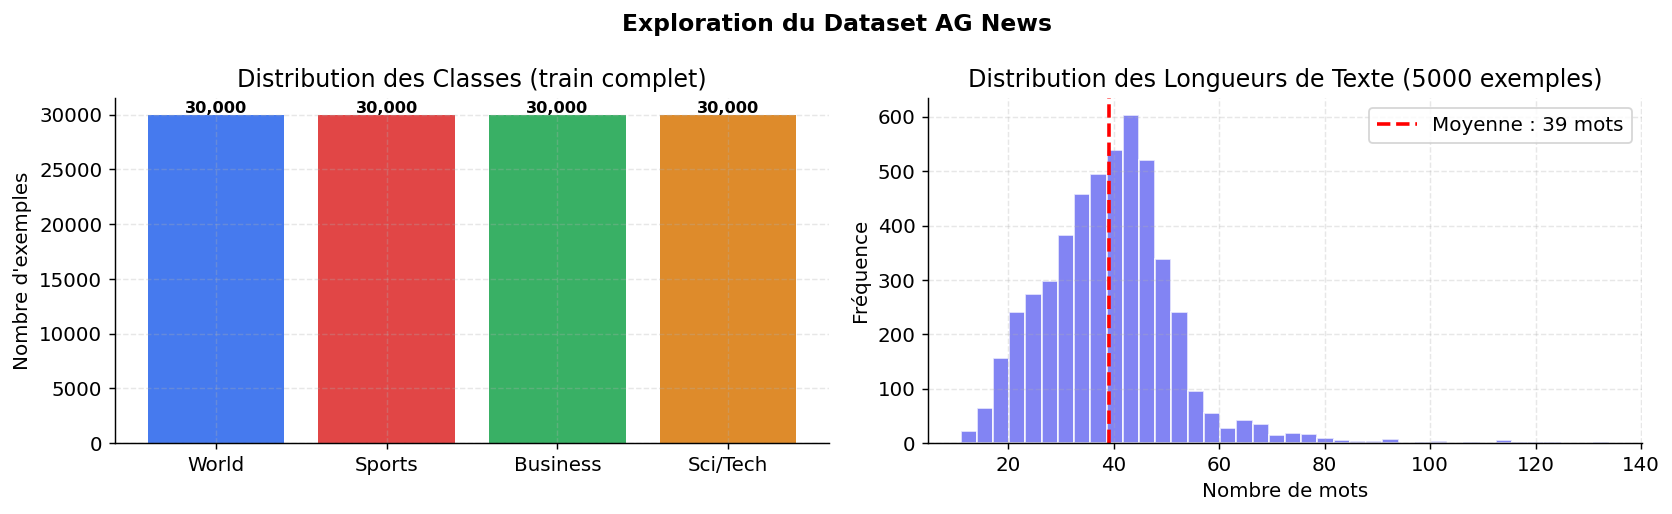

✅ Figure 0 sauvegardée → results/figures/00_data_exploration.png


In [4]:
set_seed(cfg.project.seed)
CLASS_NAMES = ["World", "Sports", "Business", "Sci/Tech"]
CLASS_COLORS = ["#2563EB", "#DC2626", "#16A34A", "#D97706"]

print("Chargement AG News depuis HuggingFace...")
raw = load_ag_news_raw()

print(f"\n📊 Dataset complet :")
print(f"   Train : {len(raw['train']):,} exemples")
print(f"   Test  : {len(raw['test']):,} exemples")
print(f"   Classes : {CLASS_NAMES}")

# Distribution des classes — dataset complet
train_labels = [ex["label"] for ex in raw["train"]]
dist = Counter(train_labels)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Exploration du Dataset AG News", fontsize=13, fontweight="bold")

# Barplot classes
bars = axes[0].bar(CLASS_NAMES, [dist[i] for i in range(4)], color=CLASS_COLORS, alpha=0.85)
axes[0].set_title("Distribution des Classes (train complet)")
axes[0].set_ylabel("Nombre d'exemples")
for bar, val in zip(bars, [dist[i] for i in range(4)]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f"{val:,}", ha="center", fontsize=9, fontweight="bold")

# Longueurs de texte
sample_lengths = [len(ex["text"].split()) for ex in raw["train"]][:5000]
axes[1].hist(sample_lengths, bins=40, color="#6366F1", alpha=0.8, edgecolor="white")
axes[1].axvline(np.mean(sample_lengths), color="red", linestyle="--",
                linewidth=2, label=f"Moyenne : {np.mean(sample_lengths):.0f} mots")
axes[1].set_title("Distribution des Longueurs de Texte (5000 exemples)")
axes[1].set_xlabel("Nombre de mots")
axes[1].set_ylabel("Fréquence")
axes[1].legend()

plt.tight_layout()
plt.savefig("results/figures/00_data_exploration.png", bbox_inches="tight")
plt.show()
print("✅ Figure 0 sauvegardée → results/figures/00_data_exploration.png")

In [5]:
# ── Exemples d'articles par classe ──
print("📰 Exemples d'articles par classe\n")
seen = set()
for ex in raw["train"]:
    if ex["label"] not in seen:
        seen.add(ex["label"])
        print(f"  [{CLASS_NAMES[ex['label']].upper()}]")
        print(f"  {ex['text'][:220]}...")
        print()
    if len(seen) == 4:
        break

📰 Exemples d'articles par classe

  [BUSINESS]
  Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again....

  [SCI/TECH]
  'Madden,' 'ESPN' Football Score in Different Ways (Reuters) Reuters - Was absenteeism a little high\on Tuesday among the guys at the office? EA Sports would like\to think it was because "Madden NFL 2005" came out that da...

  [SPORTS]
  Phelps, Thorpe Advance in 200 Freestyle (AP) AP - Michael Phelps took care of qualifying for the Olympic 200-meter freestyle semifinals Sunday, and then found out he had been added to the American team for the evening's ...

  [WORLD]
  Venezuelans Vote Early in Referendum on Chavez Rule (Reuters) Reuters - Venezuelans turned out early\and in large numbers on Sunday to vote in a historic referendum\that will either remove left-wing President Hugo Chavez...



In [6]:
# ── Préparation des sous-ensembles ──
print("Préparation datasets (sous-échantillonnage équilibré + tokenisation)...")
print(f"  {cfg.data.samples_per_class_train} exemples × {cfg.data.num_classes} classes = {cfg.data.samples_per_class_train * cfg.data.num_classes} train")
print(f"  max_length = {cfg.data.max_length} tokens (économie mémoire CPU)\n")

train_ds, val_ds, test_ds = prepare_data(cfg)

print(f"✅ Datasets tokenisés :")
print(f"   Train : {len(train_ds)} exemples")
print(f"   Val   : {len(val_ds)} exemples")
print(f"   Test  : {len(test_ds)} exemples")

# Vérification d'un item
item = train_ds[0]
print(f"\n   item[0] keys         : {list(item.keys())}")
print(f"   input_ids shape      : {item['input_ids'].shape}")
print(f"   attention_mask shape : {item['attention_mask'].shape}")
print(f"   label                : {item['labels'].item()} ({CLASS_NAMES[item['labels'].item()]})")

Préparation datasets (sous-échantillonnage équilibré + tokenisation)...
  100 exemples × 4 classes = 400 train
  max_length = 128 tokens (économie mémoire CPU)


[DATA] Chargement AG News...
  Chargement AG News depuis HuggingFace...
  Train : 120000 exemples
  Test  : 7600 exemples
[DATA] Sous-échantillonnage (mode: cpu)
       Train : 100 × 4 classes = 400
       Val   : 50 × 4 classes = 200
       Test  : 50 × 4 classes = 200
[DATA] Tokenisation avec distilbert-base-uncased (max_length=128)...
[DATA] Datasets prêts ✓
[DATA] Stats sauvegardées → c:\Users\Ultra Tech\Desktop\audrey\ML OPTIMISATION\G05_AGNews\results\logs\data_stats.json
✅ Datasets tokenisés :
   Train : 400 exemples
   Val   : 200 exemples
   Test  : 200 exemples

   item[0] keys         : ['input_ids', 'attention_mask', 'labels']
   input_ids shape      : torch.Size([128])
   attention_mask shape : torch.Size([128])
   label                : 1 (Sports)


---
## 🤖 3. Chargement du Modèle DistilBERT

In [29]:
from transformers import DistilBertConfig, AutoModelForSequenceClassification, AutoTokenizer

device = torch.device(cfg.project.device)
print(f"Device : {device}")
print(f"Chargement de {cfg.model.model_name}...\n")

tokenizer = AutoTokenizer.from_pretrained(cfg.model.model_name)

# ✅ CORRECTION IMPORTANTE :
# DistilBERT utilise 'seq_classif_dropout' et NON 'hidden_dropout_prob' (qui est BERT)
# Passer le dropout via DistilBertConfig évite le TypeError
model_config = DistilBertConfig.from_pretrained(
    cfg.model.model_name,
    num_labels=cfg.model.num_labels,
    seq_classif_dropout=cfg.model.hidden_dropout_prob,
    dropout=cfg.model.hidden_dropout_prob,
)

model = AutoModelForSequenceClassification.from_pretrained(
    cfg.model.model_name,
    config=model_config,
    torch_dtype=torch.float32,
    ignore_mismatched_sizes=True,
).to(device)

if device.type == "cpu":
    torch.set_num_threads(cfg.model.num_threads)
    print(f"Threads CPU : {cfg.model.num_threads}")

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"✅ Modèle chargé : {type(model).__name__}")
print(f"   Paramètres totaux       : {total:,}")
print(f"   Paramètres entraînables : {trainable:,}")
print(f"   Num labels              : {model.num_labels}")
print(f"   Tokenizer               : {type(tokenizer).__name__}")

Device : cpu
Chargement de distilbert-base-uncased...



Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Threads CPU : 4
✅ Modèle chargé : DistilBertForSequenceClassification
   Paramètres totaux       : 66,956,548
   Paramètres entraînables : 66,956,548
   Num labels              : 4
   Tokenizer               : DistilBertTokenizerFast


In [9]:
# ── Architecture DistilBERT (résumé) ──
print("Architecture DistilBERT :")
for name, module in list(model.named_children())[:5]:
    n_params = sum(p.numel() for p in module.parameters())
    print(f"   {name:30s} : {n_params:>10,} paramètres")

Architecture DistilBERT :
   distilbert                     : 66,362,880 paramètres
   pre_classifier                 :    590,592 paramètres
   classifier                     :      3,076 paramètres
   dropout                        :          0 paramètres


---
## ⚙️ 4. Test des 3 Optimiseurs (P01)

In [10]:
print("Test des 3 optimiseurs (Problématique P01)\n")

for opt_name in ["adamw", "sgd", "adafactor"]:
    m   = load_fresh_model(cfg)
    opt = build_optimizer(m, opt_name, lr=2e-5, weight_decay=0.01)
    print(f"  {LABELS[opt_name]:22s} → {type(opt).__name__:20s} | {len(opt.param_groups)} groupes ✓")

print("\n📚 Justifications théoriques (P01) :")
print("  AdamW     → Standard fine-tuning Transformers (Loshchilov & Hutter, 2019)")
print("            → Corrige le weight decay d'Adam classique")
print("  SGD       → Minima potentiellement plus plats (Keskar et al., 2017)")
print("            → Meilleure généralisation mais plus difficile à tuner")
print("  Adafactor → Mémoire réduite O(n+m) vs O(n×m) (Shazeer & Stern, 2018)")
print("            → Idéal pour CPU avec RAM limitée")

Test des 3 optimiseurs (Problématique P01)



Loading weights: 100%|██████████| 100/100 [00:00<00:00, 162.90it/s, Materializing param=distilbert.transformer.layer.5.sa_layer_norm.weight]   
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  AdamW                  → AdamW                | 2 groupes ✓


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 163.07it/s, Materializing param=distilbert.transformer.layer.5.sa_layer_norm.weight]   
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  SGD + Nesterov         → SGD                  | 1 groupes ✓


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 168.59it/s, Materializing param=distilbert.transformer.layer.5.sa_layer_norm.weight]   
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Adafactor              → Adafactor            | 1 groupes ✓

📚 Justifications théoriques (P01) :
  AdamW     → Standard fine-tuning Transformers (Loshchilov & Hutter, 2019)
            → Corrige le weight decay d'Adam classique
  SGD       → Minima potentiellement plus plats (Keskar et al., 2017)
            → Meilleure généralisation mais plus difficile à tuner
  Adafactor → Mémoire réduite O(n+m) vs O(n×m) (Shazeer & Stern, 2018)
            → Idéal pour CPU avec RAM limitée


---
## 🔄 5. Forward Pass & Métriques Baseline

In [11]:
val_loader = get_dataloader(val_ds, batch_size=8, shuffle=False)
batch_test = next(iter(val_loader))

model.eval()
with torch.no_grad():
    outputs = model(
        input_ids      = batch_test["input_ids"].to(device),
        attention_mask = batch_test["attention_mask"].to(device),
        labels         = batch_test["labels"].to(device)
    )

preds     = torch.argmax(outputs.logits, dim=-1).cpu().numpy()
labels_np = batch_test["labels"].numpy()
metrics   = compute_metrics(preds, labels_np)

print("✅ Forward pass OK")
print(f"   Loss    : {outputs.loss.item():.4f}")
print(f"   Logits  : {outputs.logits.shape}  (batch=8, classes=4)")
print(f"\n   Accuracy (1 batch) : {metrics['accuracy']:.4f}")
print(f"   F1 macro (1 batch) : {metrics['f1']:.4f}")

✅ Forward pass OK
   Loss    : 1.4021
   Logits  : torch.Size([8, 4])  (batch=8, classes=4)

   Accuracy (1 batch) : 0.1250
   F1 macro (1 batch) : 0.0556


In [12]:
# ── Évaluation baseline complète sur validation ──
print("Évaluation baseline complète (modèle pré-entraîné, sans fine-tuning)...")
val_loader = get_dataloader(val_ds, batch_size=8, shuffle=False)
baseline   = evaluate(model, val_loader, device)

print(f"\n📊 Baseline DistilBERT (pré-entraîné, 0 fine-tuning) :")
print(f"   Loss     : {baseline['loss']:.4f}")
print(f"   Accuracy : {baseline['accuracy']:.4f}  ({baseline['accuracy']*100:.1f}%)")
print(f"   F1 Macro : {baseline['f1']:.4f}")
print(f"\n   Référence random chance : {1/cfg.data.num_classes:.4f} ({100/cfg.data.num_classes:.0f}%)")
print(f"   → Le modèle pré-entraîné devrait déjà faire mieux que random")

Évaluation baseline complète (modèle pré-entraîné, sans fine-tuning)...

📊 Baseline DistilBERT (pré-entraîné, 0 fine-tuning) :
   Loss     : 1.3856
   Accuracy : 0.2700  (27.0%)
   F1 Macro : 0.1862

   Référence random chance : 0.2500 (25%)
   → Le modèle pré-entraîné devrait déjà faire mieux que random


---
## 🔍 6. Random Search Complet (P01)

> ⚠️ **Cette cellule peut prendre 1 à 5 heures selon ton mode.**
> Estimation : `cpu_low` → ~1-2h | `cpu_mid` → ~3-5h | `gpu` → ~30min
>
> Les résultats sont sauvegardés en temps réel dans `results/logs/` — tu peux reprendre si ça plante.

In [13]:
# ── Aperçu du plan de trials avant lancement ──
trials = generate_trial_list(cfg)

df_plan = pd.DataFrame([{
    "run_id": t.run_id, "optimizer": t.optimizer,
    "lr": f"{t.lr:.2e}", "batch_size": t.batch_size,
    "warmup": t.warmup_steps, "epochs": t.num_epochs,
} for t in trials])

print(f"📋 Plan : {len(trials)} trials")
print(f"   Répartition : {dict(Counter(t.optimizer for t in trials))}")
print(f"   Couverture garantie : {cfg.search.min_trials_per_optimizer} trials min par optimiseur\n")
display(df_plan)

📋 Plan : 20 trials
   Répartition : {'adamw': 7, 'sgd': 8, 'adafactor': 5}
   Couverture garantie : 3 trials min par optimiseur



,run_id,optimizer,lr,batch_size,warmup,epochs
0,run_000,adamw,1.03e-05,8,0,3
1,run_001,sgd,1.14e-06,16,0,3
2,run_002,adamw,3.97e-05,8,0,3
3,run_003,sgd,6.64e-06,16,100,2
4,run_004,sgd,1.47e-05,8,100,3
5,run_005,adamw,6.14e-06,16,0,3
6,run_006,adamw,9.45e-05,8,0,2
7,run_007,sgd,4.19e-05,8,500,2
8,run_008,adafactor,4.04e-04,8,500,2
9,run_009,sgd,7.03e-05,8,0,2


In [14]:
# ── LANCEMENT DU RANDOM SEARCH ──
print(f"🚀 Lancement Random Search — {len(trials)} trials (mode={MODE})")
print(f"   Estimation : {'~1-2h' if MODE=='cpu_low' else '~3-5h' if MODE=='cpu_mid' else '~30min'}")
print("   Résultats sauvegardés dans results/logs/ au fur et à mesure\n")

all_results = run_random_search(cfg, test_run=False, verbose=True)

print(f"\n✅ Random Search terminé — {len(all_results)} trials réussis")

🚀 Lancement Random Search — 20 trials (mode=cpu_mid)
   Estimation : ~3-5h
   Résultats sauvegardés dans results/logs/ au fur et à mesure


[SEARCH] Préparation des données...

[DATA] Chargement AG News...
  Chargement AG News depuis HuggingFace...
  Train : 120000 exemples
  Test  : 7600 exemples
[DATA] Sous-échantillonnage (mode: cpu)
       Train : 100 × 4 classes = 400
       Val   : 50 × 4 classes = 200
       Test  : 50 × 4 classes = 200
[DATA] Tokenisation avec distilbert-base-uncased (max_length=128)...
[DATA] Datasets prêts ✓
[DATA] Stats sauvegardées → c:\Users\Ultra Tech\Desktop\audrey\ML OPTIMISATION\G05_AGNews\results\logs\data_stats.json

[SEARCH] 20 trials à exécuter
[SEARCH] Optimiseurs : ['adamw', 'sgd', 'adafactor']
         adamw      → 7 trials
         sgd        → 8 trials
         adafactor  → 5 trials

[SEARCH] Trial 1/20

  Trial run_000 | optimizer=adamw | lr=1.03e-05
  batch=8 | warmup=0 | epochs=3


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 113.40it/s, Materializing param=distilbert.transformer.layer.5.sa_layer_norm.weight]   
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



[TRAIN] Run run_000 | max_steps=100 | eval_steps=25


  [Step   25] val_loss=1.2809 | val_acc=0.6950 | val_f1=0.6950


  [Step   50] val_loss=1.0917 | val_acc=0.8100 | val_f1=0.8091


...

  [Step   50] val_loss=0.6367 | val_acc=0.8450 | val_f1=0.8428


Epoch 6:  80%|████████  | 20/25 [03:17<01:22, 16.56s/it, loss=0.3405, step=75]

  [Step   75] val_loss=0.4922 | val_acc=0.8450 | val_f1=0.8439


  [Step  100] val_loss=0.4709 | val_acc=0.8450 | val_f1=0.8438



[TRAIN] Run run_019 terminé en 52.6 min
        val_accuracy=0.8450 | val_f1=0.8439

[SEARCH] ✓ Résultats sauvegardés → c:\Users\Ultra Tech\Desktop\audrey\ML OPTIMISATION\G05_AGNews\results\logs\random_search_results_cpu_mid.csv
[SEARCH] ✓ JSON complet → c:\Users\Ultra Tech\Desktop\audrey\ML OPTIMISATION\G05_AGNews\results\logs\all_results.json

  RÉSUMÉ RANDOM SEARCH
  adamw      | best=0.8640 | mean=0.7185 | n=7
  adafactor  | best=0.8455 | mean=0.8222 | n=5
  sgd        | best=0.2247 | mean=0.1782 | n=8

  MEILLEUR GLOBAL : adamw | F1=0.8640

✅ Random Search terminé — 20 trials réussis


---
## 📊 7. Analyse des Résultats

In [7]:
os.listdir()

['dashboard_g05.py',
 'notebooks',
 'optimiseurs',
 'README.md',
 'requirements.txt',
 'results',
 'run_experiments.sh',
 'run_experiments_.sh',
 'src']

In [8]:
if not os.path.exists(CSV_PATH):
    print(f"❌ CSV non trouvé : {CSV_PATH}")
    print("   Lance la cellule Random Search (section 6) d'abord.")
else:
    df = pd.read_csv(CSV_PATH)
    print(f"✅ {len(df)} résultats chargés\n")

    # Résumé par optimiseur
    summary = df.groupby("optimizer").agg(
        Best_F1   = ("final_val_f1",       "max"),
        Mean_F1   = ("final_val_f1",       "mean"),
        Std_F1    = ("final_val_f1",       "std"),
        Best_Acc  = ("final_val_accuracy", "max"),
        Mean_Acc  = ("final_val_accuracy", "mean"),
        Temps_moy = ("train_time_min",     "mean"),
        N_Trials  = ("run_id",             "count"),
    ).round(4)
    summary.index = [LABELS.get(i, i) for i in summary.index]

    print("📊 RÉSUMÉ PAR OPTIMISEUR")
    print("="*70)
    display(summary)

    print("\n🏆 TOP 5 RUNS GLOBAUX (par F1)")
    print("="*70)
    cols = ["run_id","optimizer","lr","batch_size","warmup_steps",
            "final_val_accuracy","final_val_f1","train_time_min"]
    top5 = df.nlargest(5, "final_val_f1")[cols].copy()
    top5["optimizer"] = top5["optimizer"].map(lambda x: LABELS.get(x, x))
    top5["lr"]        = top5["lr"].apply(lambda x: f"{x:.2e}")
    display(top5.reset_index(drop=True))

    best = df.loc[df["final_val_f1"].idxmax()]
    print(f"\n🥇 MEILLEUR GLOBAL : {LABELS.get(best['optimizer'], best['optimizer'])}")
    print(f"   LR={best['lr']:.2e} | batch={int(best['batch_size'])} | warmup={int(best['warmup_steps'])}")
    print(f"   F1={best['final_val_f1']:.4f} | Acc={best['final_val_accuracy']:.4f} | Temps={best['train_time_min']:.1f}min")

✅ 20 résultats chargés

📊 RÉSUMÉ PAR OPTIMISEUR


,Best_F1,Mean_F1,Std_F1,Best_Acc,Mean_Acc,Temps_moy,N_Trials
Adafactor,0.8455,0.8222,0.0373,0.845,0.8240,28.1820,5
AdamW,0.8640,0.7185,0.2063,0.865,0.7314,20.5900,7
SGD + Nesterov,0.2247,0.1782,0.0479,0.340,0.2938,19.8038,8



🏆 TOP 5 RUNS GLOBAUX (par F1)


,run_id,optimizer,lr,batch_size,warmup_steps,final_val_accuracy,final_val_f1,train_time_min
0,run_002,AdamW,3.97e-05,8,0,0.865,0.8640,18.33
1,run_006,AdamW,9.45e-05,8,0,0.860,0.8587,15.96
2,run_008,Adafactor,4.04e-04,8,500,0.845,0.8455,14.16
3,run_019,Adafactor,1.70e-05,16,500,0.845,0.8439,52.58
4,run_005,AdamW,6.14e-06,16,0,0.845,0.8438,33.68



🥇 MEILLEUR GLOBAL : AdamW
   LR=3.97e-05 | batch=8 | warmup=0
   F1=0.8640 | Acc=0.8650 | Temps=18.3min


---
## 📈 8. Courbes de Convergence

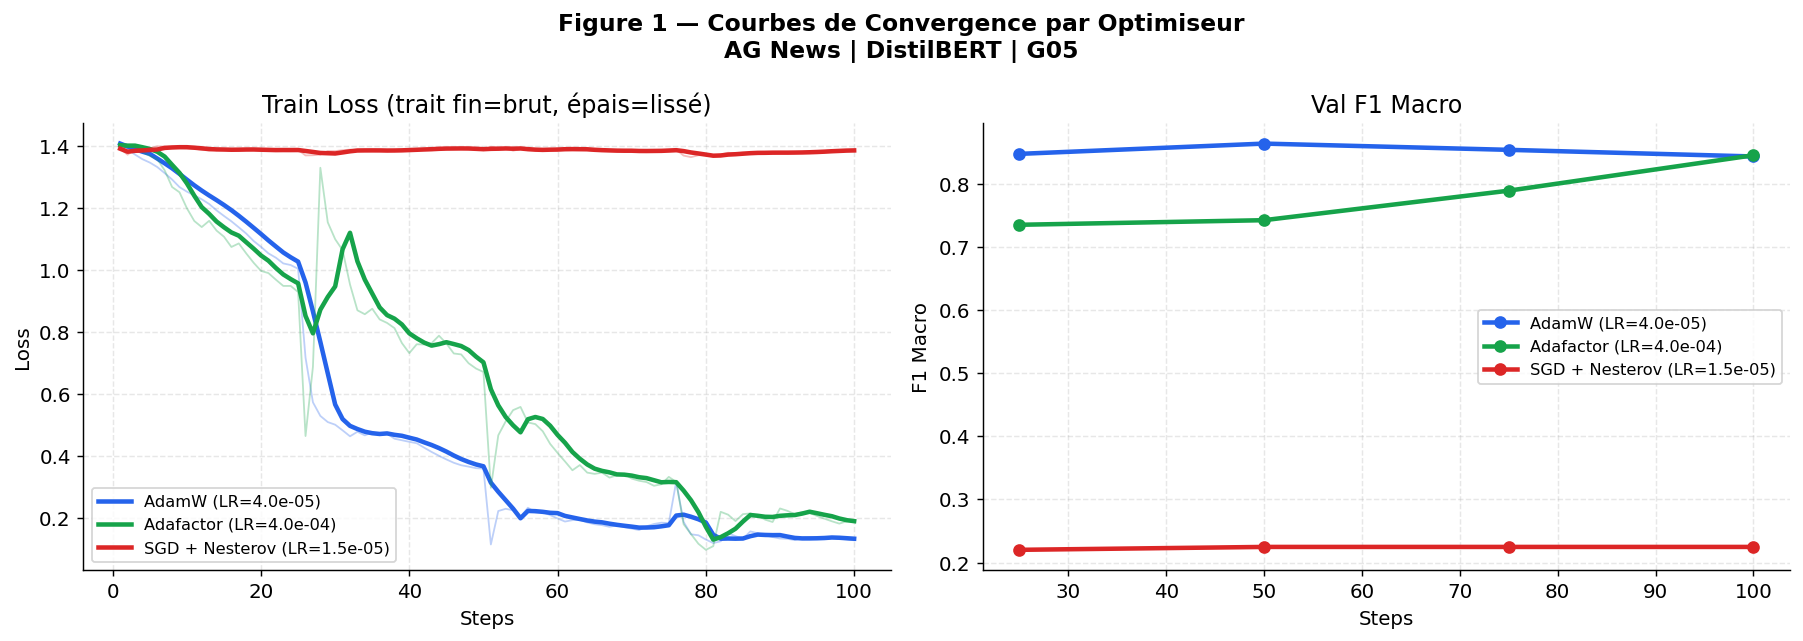

✅ Figure 1 sauvegardée


In [9]:
if not os.path.exists(HIST_PATH):
    print("❌ Historiques non trouvés. Lance Random Search d'abord.")
else:
    with open(HIST_PATH) as f:
        histories = json.load(f)

    # Meilleur run par optimiseur
    best_by_opt = {}
    for h in histories:
        opt   = h["optimizer"]
        vhist = h.get("val_metrics_history", [])
        if not vhist:
            continue
        bf1 = max(v["f1"] for v in vhist)
        if opt not in best_by_opt or bf1 > best_by_opt[opt]["best_f1"]:
            best_by_opt[opt] = {**h, "best_f1": bf1}

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Figure 1 — Courbes de Convergence par Optimiseur\nAG News | DistilBERT | G05",
                 fontsize=13, fontweight="bold")

    for opt, data in best_by_opt.items():
        color = COLORS.get(opt, "gray")
        label = f"{LABELS.get(opt, opt)} (LR={data['lr']:.1e})"

        # Train loss + lissage
        losses = data.get("train_loss_history", [])
        if losses:
            steps = list(range(1, len(losses)+1))
            axes[0].plot(steps, losses, color=color, linewidth=1, alpha=0.3)
            smooth = pd.Series(losses).rolling(5, min_periods=1).mean().values
            axes[0].plot(steps, smooth, color=color, linewidth=2.5, label=label)

        # Val F1
        vhist = data.get("val_metrics_history", [])
        if vhist:
            sv  = [v["step"] for v in vhist]
            f1v = [v["f1"]   for v in vhist]
            axes[1].plot(sv, f1v, color=color, linewidth=2.5, marker="o", markersize=6, label=label)

    for ax, title, ylabel in [
        (axes[0], "Train Loss (trait fin=brut, épais=lissé)", "Loss"),
        (axes[1], "Val F1 Macro", "F1 Macro"),
    ]:
        ax.set_title(title)
        ax.set_xlabel("Steps")
        ax.set_ylabel(ylabel)
        ax.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig("results/figures/fig1_convergence.png", bbox_inches="tight")
    plt.show()
    print("✅ Figure 1 sauvegardée")

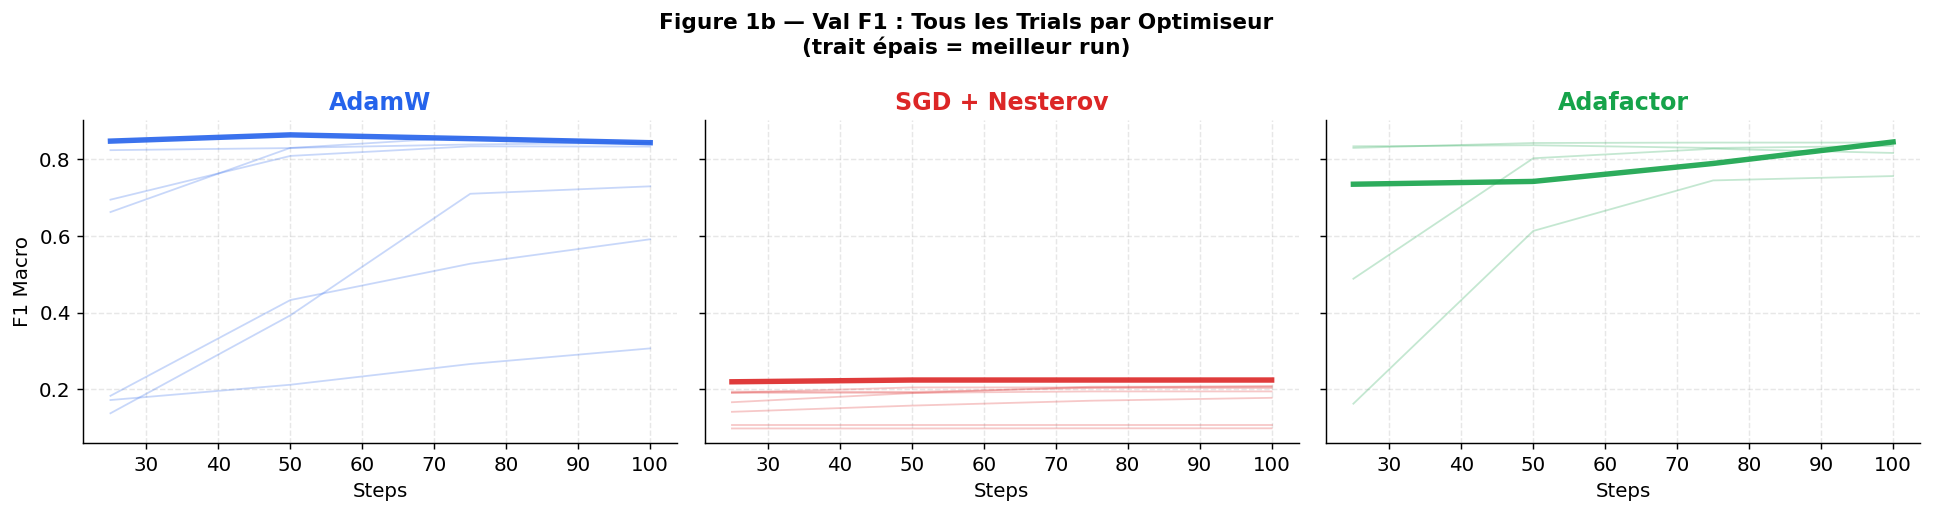

✅ Figure 1b sauvegardée


In [10]:
# ── Tous les trials par optimiseur (trait épais = meilleur) ──
if os.path.exists(HIST_PATH):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
    fig.suptitle("Figure 1b — Val F1 : Tous les Trials par Optimiseur\n(trait épais = meilleur run)",
                 fontsize=12, fontweight="bold")

    for ax, opt in zip(axes, ["adamw", "sgd", "adafactor"]):
        color    = COLORS.get(opt, "gray")
        opt_runs = [h for h in histories if h["optimizer"] == opt]
        ax.set_title(LABELS.get(opt, opt), fontweight="bold", color=color)
        ax.set_xlabel("Steps")
        if ax is axes[0]:
            ax.set_ylabel("F1 Macro")

        if not opt_runs:
            continue
        # Trouver le meilleur F1
        best_f1_opt = max(
            (max((v["f1"] for v in h.get("val_metrics_history", [{"f1": 0}])), default=0)
             for h in opt_runs), default=0
        )
        for h in opt_runs:
            vhist = h.get("val_metrics_history", [])
            if not vhist:
                continue
            sv  = [v["step"] for v in vhist]
            f1v = [v["f1"]   for v in vhist]
            is_best = abs(max(f1v) - best_f1_opt) < 1e-6
            ax.plot(sv, f1v, color=color,
                    linewidth=3 if is_best else 1,
                    alpha=0.9 if is_best else 0.25)

    plt.tight_layout()
    plt.savefig("results/figures/fig1b_all_trials.png", bbox_inches="tight")
    plt.show()
    print("✅ Figure 1b sauvegardée")

---
## 🔥 9. Heatmap Optimiseur × Learning Rate

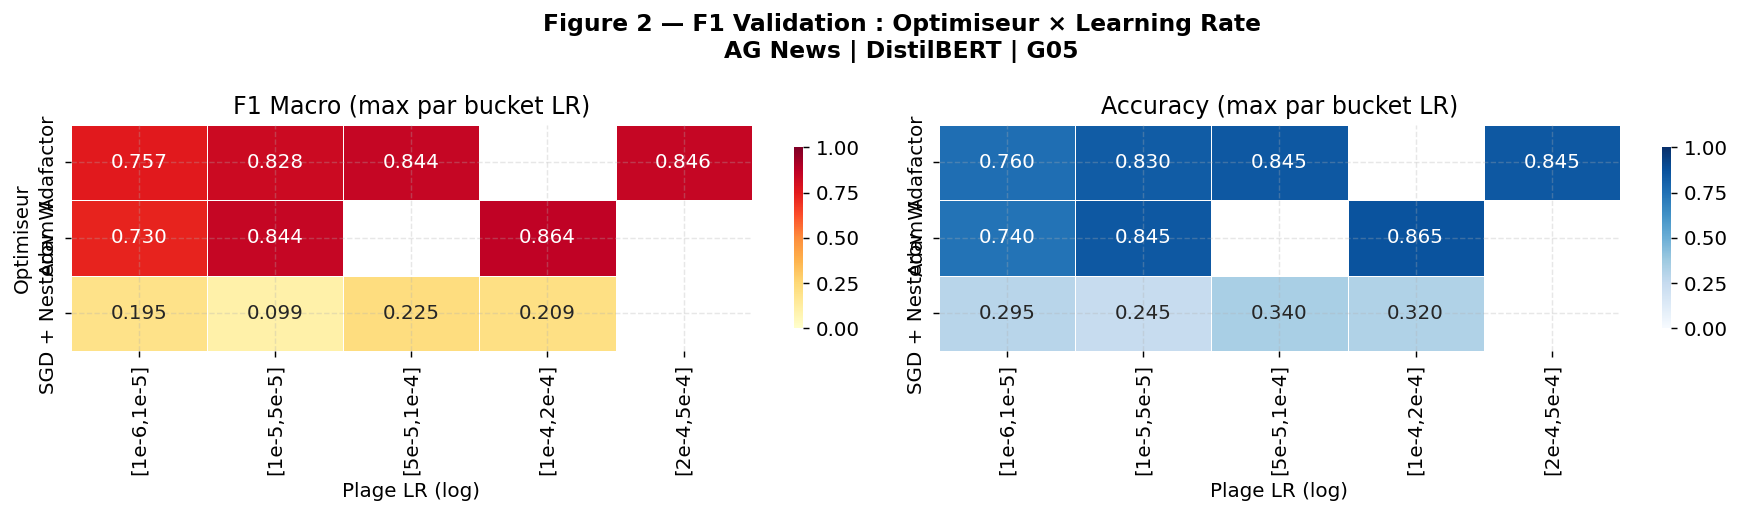

✅ Figure 2 sauvegardée


In [11]:
if not os.path.exists(CSV_PATH):
    print("❌ Lance Random Search d'abord.")
else:
    df = pd.read_csv(CSV_PATH)
    df["lr_log"]    = np.log10(df["lr"].astype(float))
    df["lr_bucket"] = pd.cut(df["lr_log"], bins=5,
                             labels=["[1e-6,1e-5]","[1e-5,5e-5]","[5e-5,1e-4]","[1e-4,2e-4]","[2e-4,5e-4]"])

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle("Figure 2 — F1 Validation : Optimiseur × Learning Rate\nAG News | DistilBERT | G05",
                 fontsize=13, fontweight="bold")

    for ax, metric, cmap, title in [
        (axes[0], "final_val_f1",       "YlOrRd", "F1 Macro (max par bucket LR)"),
        (axes[1], "final_val_accuracy", "Blues",  "Accuracy (max par bucket LR)"),
    ]:
        pivot = df.pivot_table(values=metric, index="optimizer",
                               columns="lr_bucket", aggfunc="max")
        pivot.index = [LABELS.get(i, i) for i in pivot.index]
        sns.heatmap(pivot, ax=ax, annot=True, fmt=".3f", cmap=cmap,
                    vmin=0, vmax=1, linewidths=0.5, cbar_kws={"shrink": 0.8})
        ax.set_title(title)
        ax.set_xlabel("Plage LR (log)")
        ax.set_ylabel("Optimiseur" if ax is axes[0] else "")

    plt.tight_layout()
    plt.savefig("results/figures/fig2_heatmap.png", bbox_inches="tight")
    plt.show()
    print("✅ Figure 2 sauvegardée")

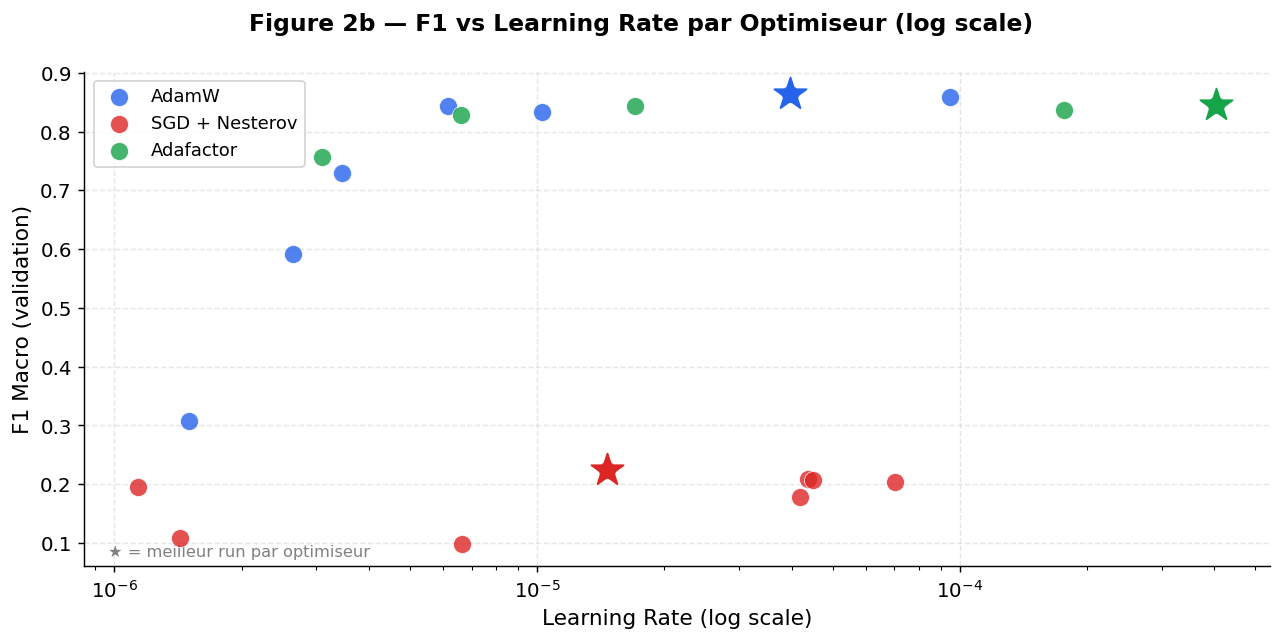

✅ Figure 2b sauvegardée


In [13]:
# ── Scatter LR vs F1 ──
if os.path.exists(CSV_PATH):
    df = pd.read_csv(CSV_PATH)
    fig, ax = plt.subplots(figsize=(10, 5))
    fig.suptitle("Figure 2b — F1 vs Learning Rate par Optimiseur (log scale)",
                 fontsize=13, fontweight="bold")

    for opt in ["adamw", "sgd", "adafactor"]:
        sub = df[df["optimizer"] == opt]
        if sub.empty:
            continue
        ax.scatter(sub["lr"], sub["final_val_f1"],
                   color=COLORS[opt], label=LABELS[opt], s=100,
                   alpha=0.8, zorder=5, edgecolors="white", linewidth=0.5)
        best_row = sub.loc[sub["final_val_f1"].idxmax()]
        ax.scatter(best_row["lr"], best_row["final_val_f1"],
                   color=COLORS[opt], s=350, marker="*", zorder=6)

    ax.set_xscale("log")
    ax.set_xlabel("Learning Rate (log scale)", fontsize=12)
    ax.set_ylabel("F1 Macro (validation)", fontsize=12)
    ax.legend(fontsize=10)
    ax.annotate("★ = meilleur run par optimiseur", xy=(0.02, 0.02),
                xycoords="axes fraction", fontsize=9, color="gray")
    plt.tight_layout()
    plt.savefig("results/figures/fig2b_lr_scatter.png", bbox_inches="tight")
    plt.show()
    print("✅ Figure 2b sauvegardée")

---
## 🏔️ 10. Loss Landscape (Li et al., 2018)

In [25]:
def compute_loss_landscape_1d(model, dataloader, cfg, direction_seed=0):
    """
    Perturbation directionnelle 1D avec filter normalization.
    Li et al. (2018) 'Visualizing the Loss Landscape of Neural Nets' — NeurIPS.

    Filter normalization (eq.4) : normalise chaque filtre de direction
    par la norme du filtre de paramètre correspondant → comparaison équitable.
    """
    lc = cfg.landscape
    torch.manual_seed(direction_seed)
    model.eval()

    original_params = [p.clone().detach() for p in model.parameters()]

    # Direction aléatoire avec filter normalization
    direction = []
    for p in model.parameters():
        d = torch.randn_like(p)
        if p.dim() > 1:
            pn = p.norm(dim=list(range(1, p.dim())), keepdim=True).clamp(min=1e-8)
            dn = d.norm(dim=list(range(1, d.dim())), keepdim=True).clamp(min=1e-8)
            d  = d * (pn / dn)
        direction.append(d)

    alphas = np.linspace(-lc.epsilon, lc.epsilon, lc.n_points)
    losses = []
    device = next(model.parameters()).device

    for alpha in alphas:
        with torch.no_grad():
            for p, p0, d in zip(model.parameters(), original_params, direction):
                p.data = p0 + alpha * d
        total, n = 0.0, 0
        with torch.no_grad():
            for batch in dataloader:
                if n >= lc.n_samples_eval:
                    break
                out = model(
                    input_ids      = batch["input_ids"].to(device),
                    attention_mask = batch["attention_mask"].to(device),
                    labels         = batch["labels"].to(device)
                )
                total += out.loss.item()
                n     += 1
        losses.append(total / max(n, 1))

    # Restaurer les paramètres originaux
    with torch.no_grad():
        for p, p0 in zip(model.parameters(), original_params):
            p.data = p0.clone()

    return alphas, losses


def compute_sharpness(alphas, losses):
    """
    Sharpness = (1/N) Σ |L(θ + ε·di) - L(θ)|
    Keskar et al. (2017) — corrélé à la mauvaise généralisation.
    """
    center = losses[len(losses)//2]
    return float(np.mean([abs(l - center) for l in losses]))


print("✅ Fonctions loss landscape définies")
print("   Prêt à calculer — lance la cellule suivante")

✅ Fonctions loss landscape définies
   Prêt à calculer — lance la cellule suivante


In [27]:
os.chdir('G05_AGNews')

In [30]:
landscape_results = {}
val_loader_ls = get_dataloader(val_ds, batch_size=8, shuffle=False)

for opt in ["adamw", "sgd", "adafactor"]:
    model_path =  f"results/models/best_{opt}.pt"
    if not os.path.exists(model_path):
        print(f"⚠️  Modèle {opt} non trouvé ({model_path})")
        print("   Lance Random Search (section 6) d'abord.")
        continue

    print(f"Calcul landscape pour {LABELS[opt]}...")
    m_cfg = DistilBertConfig.from_pretrained(
        cfg.model.model_name,
        num_labels=cfg.model.num_labels,
        seq_classif_dropout=cfg.model.hidden_dropout_prob,
        dropout=cfg.model.hidden_dropout_prob,
    )
    m = AutoModelForSequenceClassification.from_pretrained(
        cfg.model.model_name, config=m_cfg,
        torch_dtype=torch.float32, ignore_mismatched_sizes=True
    ).to(device)
    m.load_state_dict(torch.load(model_path, map_location=device))
    m.eval()

    alphas, losses = compute_loss_landscape_1d(m, val_loader_ls, cfg)
    sharpness      = compute_sharpness(alphas, losses)
    landscape_results[opt] = {
        "alphas": alphas.tolist(), "losses": losses, "sharpness": sharpness
    }
    print(f"   ✓ Sharpness = {sharpness:.5f}")

# Sauvegarde
with open("results/logs/sharpness_scores.json", "w") as f:
    json.dump({k: v["sharpness"] for k, v in landscape_results.items()}, f, indent=2)

print("\n✅ Loss landscapes calculés et sauvegardés")

Calcul landscape pour AdamW...


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
'(ProtocolError('Connection aborted.', RemoteDisconnected('Remote end closed connection without response')), '(Request ID: eed13846-49bb-45bc-8cd1-61ab08408298)')' thrown while requesting HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/config.json
Retrying in 1s [Retry 1/5].


   ✓ Sharpness = 0.00460
Calcul landscape pour SGD + Nesterov...


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


   ✓ Sharpness = 0.00225
Calcul landscape pour Adafactor...


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


   ✓ Sharpness = 0.00327

✅ Loss landscapes calculés et sauvegardés


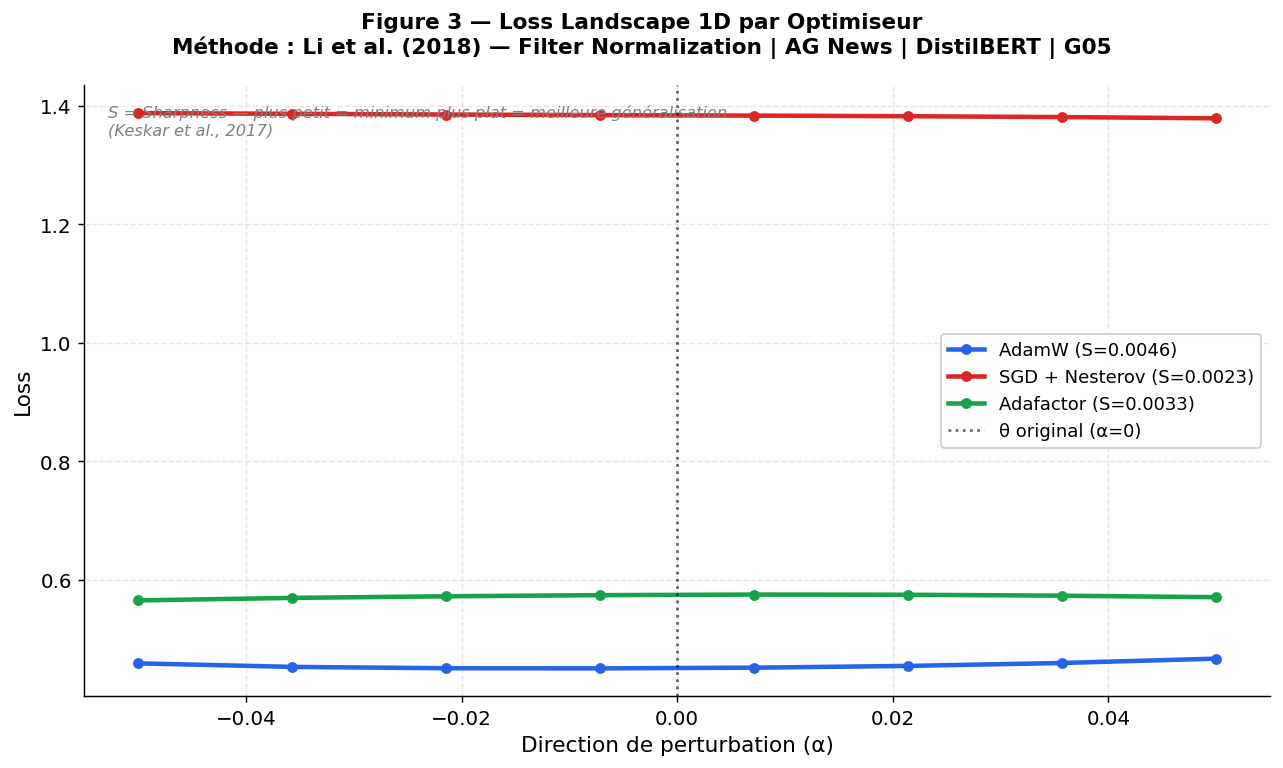

✅ Figure 3 sauvegardée


In [31]:
# ── Figure 3 : Loss Landscape 1D ──
if landscape_results:
    fig, ax = plt.subplots(figsize=(10, 6))
    fig.suptitle(
        "Figure 3 — Loss Landscape 1D par Optimiseur\n"
        "Méthode : Li et al. (2018) — Filter Normalization | AG News | DistilBERT | G05",
        fontsize=12, fontweight="bold"
    )

    for opt, data in landscape_results.items():
        label = f"{LABELS.get(opt, opt)} (S={data['sharpness']:.4f})"
        ax.plot(data["alphas"], data["losses"],
                color=COLORS.get(opt, "gray"), linewidth=2.5,
                marker="o", markersize=5, label=label)

    ax.axvline(x=0, color="black", linestyle=":", linewidth=1.5,
               alpha=0.6, label="θ original (α=0)")
    ax.set_xlabel("Direction de perturbation (α)", fontsize=12)
    ax.set_ylabel("Loss", fontsize=12)
    ax.legend(fontsize=10, framealpha=0.95)
    ax.annotate(
        "S = Sharpness — plus petit = minimum plus plat = meilleure généralisation\n"
        "(Keskar et al., 2017)",
        xy=(0.02, 0.97), xycoords="axes fraction",
        fontsize=9, color="gray", va="top", style="italic"
    )
    plt.tight_layout()
    plt.savefig("results/figures/fig3_loss_landscape.png", bbox_inches="tight")
    plt.show()
    print("✅ Figure 3 sauvegardée")

---
## 📐 11. Analyse de la Sharpness (Keskar et al., 2017)

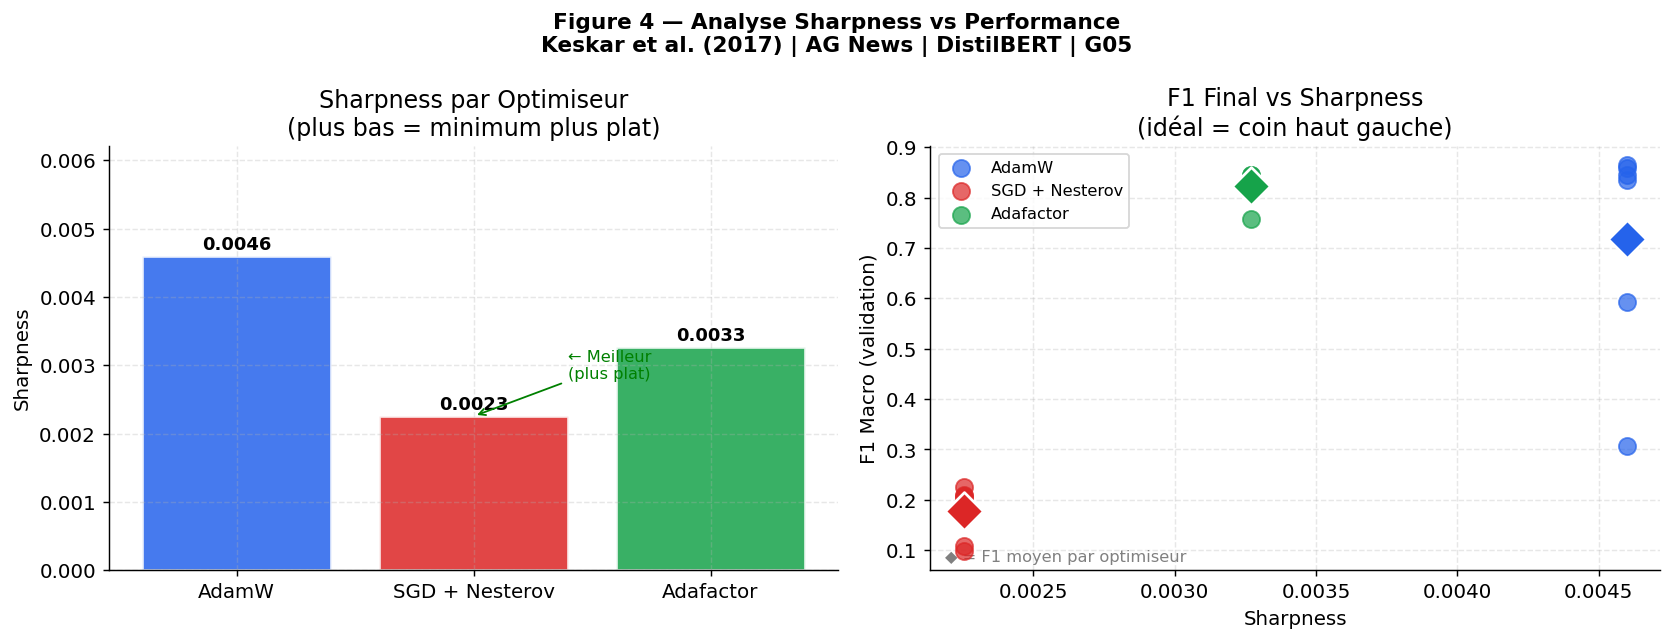

✅ Figure 4 sauvegardée


In [34]:
if landscape_results and os.path.exists(CSV_PATH):
    df = pd.read_csv(CSV_PATH)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(
        "Figure 4 — Analyse Sharpness vs Performance\n"
        "Keskar et al. (2017) | AG News | DistilBERT | G05",
        fontsize=12, fontweight="bold"
    )

    opts   = list(landscape_results.keys())
    sharps = [landscape_results[o]["sharpness"] for o in opts]
    colors = [COLORS.get(o, "gray") for o in opts]
    labels = [LABELS.get(o, o) for o in opts]

    # ── Barplot Sharpness ──
    bars = axes[0].bar(labels, sharps, color=colors, alpha=0.85,
                       edgecolor="white", linewidth=1.5)
    axes[0].set_title("Sharpness par Optimiseur\n(plus bas = minimum plus plat)")
    axes[0].set_ylabel("Sharpness")
    axes[0].set_ylim(0, max(sharps) * 1.35)
    for bar, val in zip(bars, sharps):
        axes[0].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + max(sharps)*0.02,
                     f"{val:.4f}", ha="center", fontsize=10, fontweight="bold")
    # Annotation meilleur
    best_idx = int(np.argmin(sharps))
    axes[0].annotate("← Meilleur\n(plus plat)",
                     xy=(best_idx, min(sharps)),
                     xytext=(best_idx + 0.4, min(sharps) + max(sharps)*0.12),
                     arrowprops=dict(arrowstyle="->", color="green"),
                     fontsize=9, color="green")

    # ── Scatter Sharpness vs F1 ──
    axes[1].set_title("F1 Final vs Sharpness\n(idéal = coin haut gauche)")
    axes[1].set_xlabel("Sharpness")
    axes[1].set_ylabel("F1 Macro (validation)")
    for opt in opts:
        sub   = df[df["optimizer"] == opt]
        sharp = landscape_results[opt]["sharpness"]
        axes[1].scatter([sharp]*len(sub), sub["final_val_f1"],
                        color=COLORS.get(opt, "gray"), label=LABELS.get(opt, opt),
                        alpha=0.7, s=90, zorder=5)
        # Point moyen
        axes[1].scatter(sharp, sub["final_val_f1"].mean(),
                        color=COLORS.get(opt, "gray"), s=220,
                        marker="D", zorder=6, edgecolors="white", linewidth=1.5)
    axes[1].legend(fontsize=9)
    axes[1].annotate("◆ = F1 moyen par optimiseur", xy=(0.02, 0.02),
                     xycoords="axes fraction", fontsize=9, color="gray")

    plt.tight_layout()
    plt.savefig("results/figures/fig4_sharpness.png", bbox_inches="tight")
    plt.show()
    print("✅ Figure 4 sauvegardée")

---
## 📦 12. Boxplots & Distributions

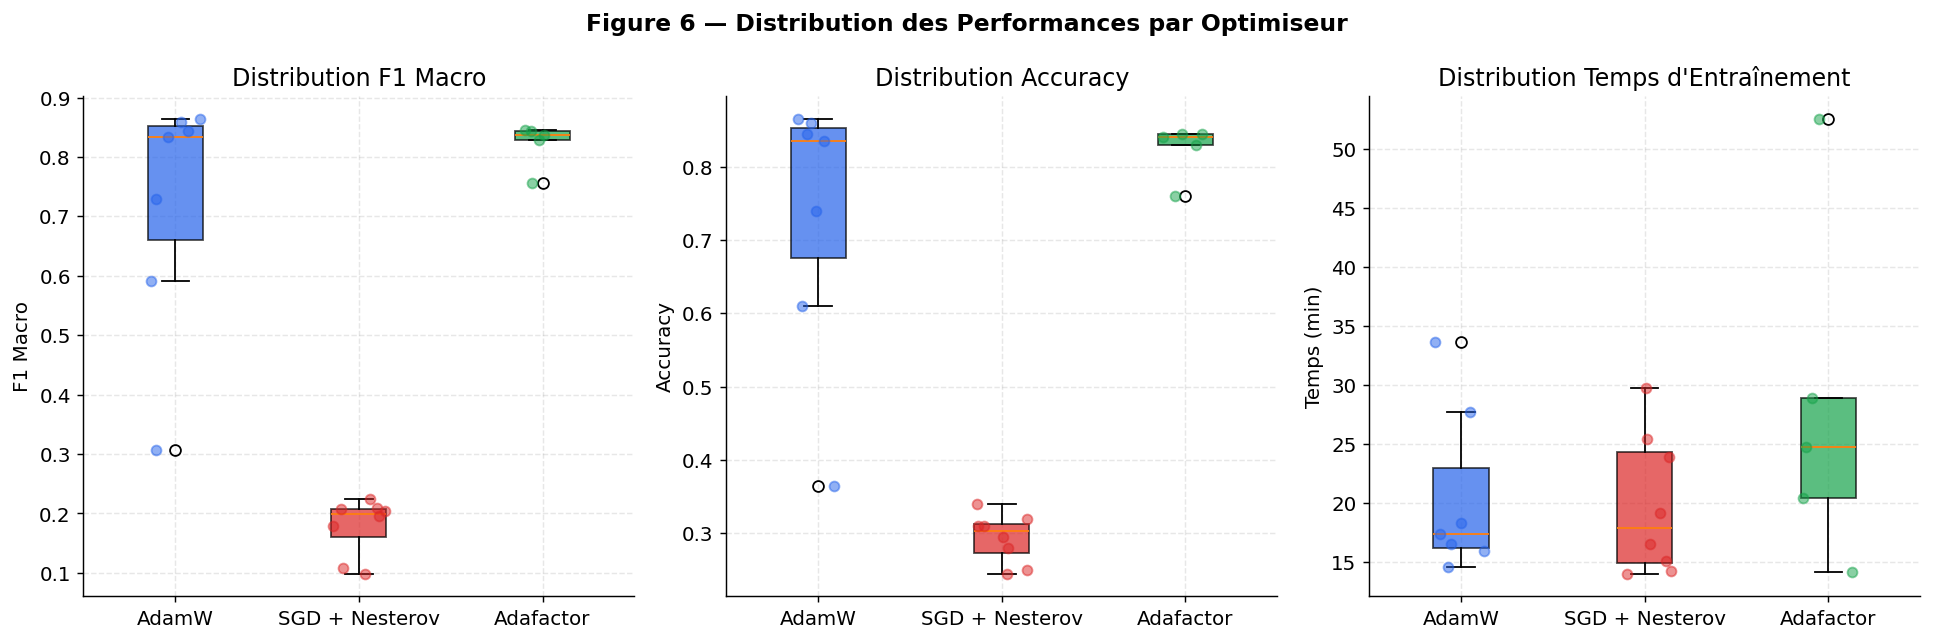

✅ Figure 6 sauvegardée


In [36]:
if os.path.exists(CSV_PATH):
    df = pd.read_csv(CSV_PATH)
    df["opt_label"] = df["optimizer"].map(LABELS)
    opt_order  = [LABELS[o] for o in ["adamw","sgd","adafactor"] if LABELS[o] in df["opt_label"].values]
    colors_lst = [COLORS[o] for o in ["adamw","sgd","adafactor"] if LABELS[o] in df["opt_label"].values]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle("Figure 6 — Distribution des Performances par Optimiseur",
                 fontsize=13, fontweight="bold")

    for ax, metric, ylabel, title in [
        (axes[0], "final_val_f1",       "F1 Macro",    "Distribution F1 Macro"),
        (axes[1], "final_val_accuracy", "Accuracy",    "Distribution Accuracy"),
        (axes[2], "train_time_min",     "Temps (min)", "Distribution Temps d'Entraînement"),
    ]:
        data_list = [df[df["opt_label"]==o][metric].values for o in opt_order]
        bp = ax.boxplot(data_list, labels=opt_order, patch_artist=True, notch=False)
        for patch, color in zip(bp["boxes"], colors_lst):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        # Points individuels
        for i, (data_pts, color) in enumerate(zip(data_list, colors_lst), 1):
            jitter = np.random.uniform(-0.15, 0.15, len(data_pts))
            ax.scatter(i + jitter, data_pts, color=color, alpha=0.5, s=30, zorder=3)
        ax.set_ylabel(ylabel)
        ax.set_title(title)

    plt.tight_layout()
    plt.savefig("results/figures/fig6_distributions.png", bbox_inches="tight")
    plt.show()
    print("✅ Figure 6 sauvegardée")

In [41]:


import os
import sys
import json
import torch
import numpy as np
from tqdm import tqdm

# Configuration du path
PROJECT_ROOT = os.path.abspath('.')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("🔧 Initialisation...")
print(f"📁 Projet: {PROJECT_ROOT}")

# Imports projet
from src.config import get_config
from src.data_loader import prepare_data, get_dataloader, set_seed
from transformers import DistilBertConfig, AutoModelForSequenceClassification

# ══════════════════════════════════════════════════════════════════════════════
# 🧮 FONCTIONS DE CALCUL LOSS LANDSCAPE
# ══════════════════════════════════════════════════════════════════════════════

def compute_loss_landscape_1d(model, dataloader, cfg, direction_seed=0):
    """
    Calcul du loss landscape 1D avec filter normalization.
    
    Méthode : Li et al. (2018) "Visualizing the Loss Landscape of Neural Nets"
    - Perturbation directionnelle aléatoire
    - Filter normalization pour comparaison équitable
    
    Args:
        model: Modèle PyTorch
        dataloader: DataLoader pour évaluation
        cfg: Configuration
        direction_seed: Seed pour reproductibilité de la direction
    
    Returns:
        alphas: Liste des coefficients de perturbation
        losses: Liste des loss correspondantes
    """
    lc = cfg.landscape
    torch.manual_seed(direction_seed)
    model.eval()
    device = next(model.parameters()).device
    
    print(f"  📐 Génération direction aléatoire (seed={direction_seed})...")
    
    # Sauvegarde paramètres originaux
    original_params = [p.clone().detach() for p in model.parameters()]
    
    # Génération direction avec filter normalization
    direction = []
    for p in model.parameters():
        d = torch.randn_like(p)
        
        # Filter normalization (Li et al. 2018, eq. 4)
        if p.dim() > 1:
            # Normalise chaque filtre par la norme du filtre correspondant
            p_norm = p.norm(dim=list(range(1, p.dim())), keepdim=True).clamp(min=1e-8)
            d_norm = d.norm(dim=list(range(1, d.dim())), keepdim=True).clamp(min=1e-8)
            d = d * (p_norm / d_norm)
        
        direction.append(d)
    
    print(f"  📊 Échantillonnage {lc.n_points} points de α={-lc.epsilon} à α={lc.epsilon}...")
    
    # Plage de perturbation
    alphas = np.linspace(-lc.epsilon, lc.epsilon, lc.n_points)
    losses = []
    
    # Calcul loss pour chaque alpha
    for alpha in tqdm(alphas, desc="  Calcul landscape", ncols=80):
        # Application de la perturbation
        with torch.no_grad():
            for p, p0, d in zip(model.parameters(), original_params, direction):
                p.data = p0 + alpha * d
        
        # Évaluation de la loss
        total_loss = 0.0
        n_batches = 0
        
        with torch.no_grad():
            for batch in dataloader:
                if n_batches >= lc.n_samples_eval:
                    break
                
                outputs = model(
                    input_ids=batch["input_ids"].to(device),
                    attention_mask=batch["attention_mask"].to(device),
                    labels=batch["labels"].to(device)
                )
                
                total_loss += outputs.loss.item()
                n_batches += 1
        
        losses.append(total_loss / max(n_batches, 1))
    
    # Restauration des paramètres originaux
    print("  ✅ Restauration paramètres originaux...")
    with torch.no_grad():
        for p, p0 in zip(model.parameters(), original_params):
            p.data = p0.clone()
    
    return alphas.tolist(), losses


def compute_sharpness(alphas, losses):
    """
    Calcul de la sharpness selon Keskar et al. (2017).
    
    Sharpness = (1/N) Σ |L(θ + ε·di) - L(θ)|
    
    Plus la sharpness est faible, plus le minimum est plat,
    ce qui est corrélé à une meilleure généralisation.
    
    Args:
        alphas: Liste des coefficients alpha
        losses: Liste des loss correspondantes
    
    Returns:
        Valeur de sharpness (float)
    """
    # Loss au centre (alpha=0)
    center_idx = len(losses) // 2
    center_loss = losses[center_idx]
    
    # Moyenne des écarts absolus
    sharpness = np.mean([abs(l - center_loss) for l in losses])
    
    return float(sharpness)


# ══════════════════════════════════════════════════════════════════════════════
# 🚀 SCRIPT PRINCIPAL
# ══════════════════════════════════════════════════════════════════════════════

def main():
    """Fonction principale"""
    
    print("\n" + "═" * 70)
    print("  🏔️  CALCUL LOSS LANDSCAPE 1D")
    print("  G05 — AG News | DistilBERT | P01")
    print("═" * 70)
    
    # ─── Configuration ───
    print("\n📋 Chargement configuration...")
    
    # Détection automatique du mode depuis les fichiers existants
    # ou utilise la même config que le Random Search
    if os.path.exists("results/logs/random_search_results_cpu_low.csv"):
        MODE = "cpu_low"
    elif os.path.exists("results/logs/random_search_results_cpu_mid.csv"):
        MODE = "cpu_mid"
    elif os.path.exists("results/logs/random_search_results_gpu.csv"):
        MODE = "gpu"
    else:
        # Par défaut, utilise cpu_mid
        MODE = "cpu_mid"
    
    cfg = get_config(MODE)
    
    print(f"  Mode détecté: {MODE}")
    print(f"  Device: {cfg.project.device}")
    print(f"  Epsilon: ±{cfg.landscape.epsilon}")
    print(f"  Points: {cfg.landscape.n_points}")
    print(f"  Batches eval: {cfg.landscape.n_samples_eval}")
    
    # ─── Vérification des modèles ───
    print("\n🔍 Vérification des modèles...")
    optimizers_to_process = []
    
    for opt in ["adamw", "sgd", "adafactor"]:
        model_path = f"results/models/best_{opt}.pt"
        if os.path.exists(model_path):
            optimizers_to_process.append(opt)
            print(f"  ✅ {opt.upper():10s} : {model_path}")
        else:
            print(f"  ⚠️  {opt.upper():10s} : Modèle non trouvé — ignoré")
    
    if not optimizers_to_process:
        print("\n❌ ERREUR: Aucun modèle trouvé dans results/models/")
        print("   Lance d'abord le Random Search (section 6 du notebook)")
        return
    
    print(f"\n📊 {len(optimizers_to_process)} optimiseur(s) à traiter")
    
    # ─── Préparation des données ───
    print("\n📦 Préparation datasets...")
    set_seed(cfg.project.seed)
    train_ds, val_ds, test_ds = prepare_data(cfg)
    
    # Utilise le batch_size de la config au lieu de hardcoder 8
    batch_size = cfg.data.batch_size if hasattr(cfg.data, 'batch_size') else 8
    val_loader = get_dataloader(val_ds, batch_size=batch_size, shuffle=False)
    
    print(f"  Validation: {len(val_ds)} exemples")
    print(f"  Batch size: {batch_size}")
    print(f"  Seed: {cfg.project.seed}")
    
    # ─── Device ───
    device = torch.device(cfg.project.device)
    print(f"\n🖥️  Device: {device}")
    
    # ─── Calcul pour chaque optimiseur ───
    landscape_results = {}
    sharpness_scores = {}
    
    print("\n" + "─" * 70)
    print("  CALCUL DES LANDSCAPES")
    print("─" * 70)
    
    for i, opt in enumerate(optimizers_to_process, 1):
        print(f"\n[{i}/{len(optimizers_to_process)}] Optimiseur: {opt.upper()}")
        print("─" * 70)
        
        # Chargement du modèle
        print("  📥 Chargement modèle...")
        model_config = DistilBertConfig.from_pretrained(
            cfg.model.model_name,
            num_labels=cfg.model.num_labels,
            seq_classif_dropout=cfg.model.hidden_dropout_prob,
            dropout=cfg.model.hidden_dropout_prob,
        )
        
        model = AutoModelForSequenceClassification.from_pretrained(
            cfg.model.model_name,
            config=model_config,
            torch_dtype=torch.float32,
            ignore_mismatched_sizes=True
        ).to(device)
        
        # Chargement des poids entraînés
        model_path = f"results/models/best_{opt}.pt"
        model.load_state_dict(torch.load(model_path, map_location=device))
        model.eval()
        
        print(f"  ✅ Modèle chargé: {sum(p.numel() for p in model.parameters()):,} paramètres")
        
        # Calcul du landscape
        print("  🧮 Calcul loss landscape...")
        alphas, losses = compute_loss_landscape_1d(
            model, val_loader, cfg, direction_seed=cfg.project.seed
        )
        
        # Calcul de la sharpness
        sharpness = compute_sharpness(alphas, losses)
        print(f"  📐 Sharpness: {sharpness:.6f}")
        
        # Sauvegarde des résultats
        landscape_results[opt] = {
            "alphas": alphas,
            "losses": losses,
            "sharpness": sharpness,
            "epsilon": cfg.landscape.epsilon,
            "n_points": cfg.landscape.n_points,
            "n_samples_eval": cfg.landscape.n_samples_eval,
            "seed": cfg.project.seed,
            "mode": MODE,
        }
        
        sharpness_scores[opt] = sharpness
        
        print(f"  ✅ Terminé pour {opt.upper()}")
    
    # ─── Sauvegarde des résultats ───
    print("\n" + "─" * 70)
    print("  SAUVEGARDE DES RÉSULTATS")
    print("─" * 70)
    
    # Création du dossier si nécessaire
    os.makedirs("results/logs", exist_ok=True)
    
    # Sauvegarde landscape complet
    landscape_path = "results/logs/landscape_results.json"
    with open(landscape_path, 'w') as f:
        json.dump(landscape_results, f, indent=2)
    print(f"  ✅ Landscape: {landscape_path}")
    
    # Sauvegarde sharpness seul
    sharpness_path = "results/logs/sharpness_scores.json"
    with open(sharpness_path, 'w') as f:
        json.dump(sharpness_scores, f, indent=2)
    print(f"  ✅ Sharpness: {sharpness_path}")
    
    # ─── Résumé final ───
    print("\n" + "═" * 70)
    print("  ✅ CALCUL TERMINÉ")
    print("═" * 70)
    
    print("\n📊 Résultats de Sharpness (plus bas = meilleur):")
    sorted_opts = sorted(sharpness_scores.items(), key=lambda x: x[1])
    for rank, (opt, sharp) in enumerate(sorted_opts, 1):
        medal = "🥇" if rank == 1 else "🥈" if rank == 2 else "🥉" if rank == 3 else "  "
        print(f"  {medal} {rank}. {opt.upper():10s} : {sharp:.6f}")
    
    print("\n📁 Fichiers créés:")
    print(f"  • {landscape_path}")
    print(f"  • {sharpness_path}")
    
    print("\n💡 Prochaines étapes:")
    print("  1. Lance le dashboard: python dashboard_g05_enhanced.py")
    print("  2. Consulte l'onglet 'Loss Landscape' pour les visualisations")
    print("  3. Compare les sharpness dans l'onglet 'Tableau Récap'")
    
    print("\n" + "═" * 70 + "\n")


try:
    main()
except KeyboardInterrupt:
    print("\n\n⚠️  Interruption utilisateur (Ctrl+C)")
    print("   Les résultats partiels ne sont PAS sauvegardés")
    sys.exit(1)
except Exception as e:
    print(f"\n\n❌ ERREUR: {e}")
    import traceback
    traceback.print_exc()
    sys.exit(1)



'(ProtocolError('Connection aborted.', RemoteDisconnected('Remote end closed connection without response')), '(Request ID: cb5a1d9b-c22c-491b-9f97-d5810aa7b34f)')' thrown while requesting HEAD https://huggingface.co/datasets/ag_news/resolve/main/README.md
Retrying in 1s [Retry 1/5].


🔧 Initialisation...
📁 Projet: c:\Users\Ultra Tech\Desktop\audrey\ML OPTIMISATION\G05_AGNews

══════════════════════════════════════════════════════════════════════
  🏔️  CALCUL LOSS LANDSCAPE 1D
  G05 — AG News | DistilBERT | P01
══════════════════════════════════════════════════════════════════════

📋 Chargement configuration...
  Mode détecté: cpu_low
  Device: cpu
  Epsilon: ±0.05
  Points: 6
  Batches eval: 30

🔍 Vérification des modèles...
  ✅ ADAMW      : results/models/best_adamw.pt
  ✅ SGD        : results/models/best_sgd.pt
  ✅ ADAFACTOR  : results/models/best_adafactor.pt

📊 3 optimiseur(s) à traiter

📦 Préparation datasets...

[DATA] Chargement AG News...
  Chargement AG News depuis HuggingFace...
  Train : 120000 exemples
  Test  : 7600 exemples
[DATA] Sous-échantillonnage (mode: cpu)
       Train : 75 × 4 classes = 300
       Val   : 30 × 4 classes = 120
       Test  : 30 × 4 classes = 120
[DATA] Tokenisation avec distilbert-base-uncased (max_length=64)...
[DATA] Datasets 

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  ✅ Modèle chargé: 66,956,548 paramètres
  🧮 Calcul loss landscape...
  📐 Génération direction aléatoire (seed=42)...
  📊 Échantillonnage 6 points de α=-0.05 à α=0.05...


  Calcul landscape: 100%|█████████████████████████| 6/6 [01:00<00:00, 10.13s/it]


...

  ✅ Restauration paramètres originaux...
  📐 Sharpness: 0.001086
  ✅ Terminé pour SGD

[3/3] Optimiseur: ADAFACTOR
──────────────────────────────────────────────────────────────────────
  📥 Chargement modèle...


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  ✅ Modèle chargé: 66,956,548 paramètres
  🧮 Calcul loss landscape...
  📐 Génération direction aléatoire (seed=42)...
  📊 Échantillonnage 6 points de α=-0.05 à α=0.05...


  Calcul landscape: 100%|█████████████████████████| 6/6 [01:19<00:00, 13.31s/it]

  ✅ Restauration paramètres originaux...
  📐 Sharpness: 0.039769
  ✅ Terminé pour ADAFACTOR

──────────────────────────────────────────────────────────────────────
  SAUVEGARDE DES RÉSULTATS
──────────────────────────────────────────────────────────────────────
  ✅ Landscape: results/logs/landscape_results.json
  ✅ Sharpness: results/logs/sharpness_scores.json

══════════════════════════════════════════════════════════════════════
  ✅ CALCUL TERMINÉ
══════════════════════════════════════════════════════════════════════

📊 Résultats de Sharpness (plus bas = meilleur):
  🥇 1. SGD        : 0.001086
  🥈 2. ADAMW      : 0.020251
  🥉 3. ADAFACTOR  : 0.039769

📁 Fichiers créés:
  • results/logs/landscape_results.json
  • results/logs/sharpness_scores.json

💡 Prochaines étapes:
  1. Lance le dashboard: python dashboard_g05_enhanced.py
  2. Consulte l'onglet 'Loss Landscape' pour les visualisations
  3. Compare les sharpness dans l'onglet 'Tableau Récap'

═══════════════════════════════════════

---
## 📋 13. Tableau Récapitulatif Final

,Best F1,Mean F1,Best Acc,Temps moy (min),N Trials,Sharpness
Adafactor,0.8455,0.8222,0.8450,28.2,5,0.00327
AdamW,0.8640,0.7185,0.8650,20.6,7,0.00460
SGD + Nesterov,0.2247,0.1782,0.3400,19.8,8,0.00225


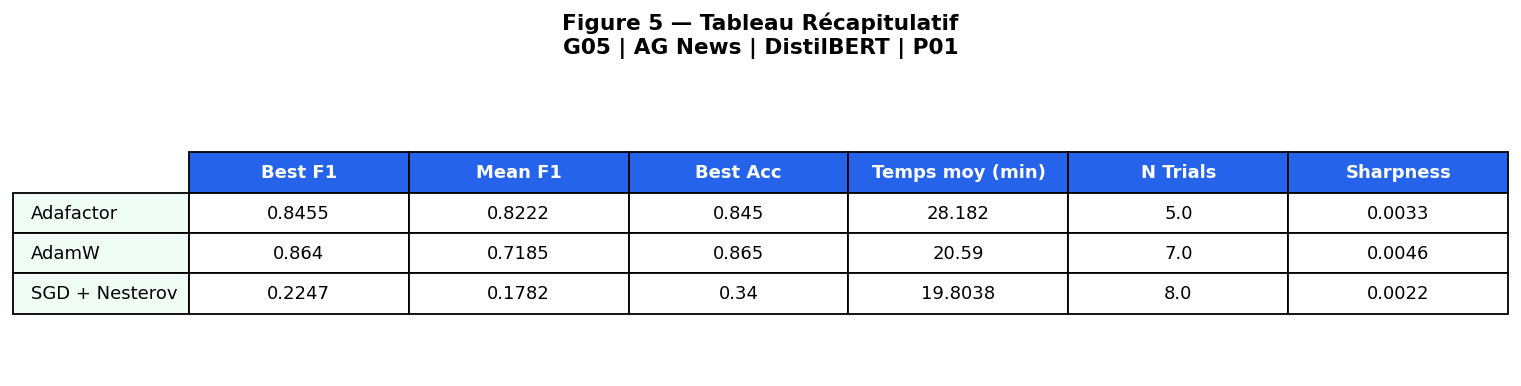

✅ Figure 5 sauvegardée


In [40]:
if os.path.exists(CSV_PATH):
    df = pd.read_csv(CSV_PATH)

    summary = df.groupby("optimizer").agg(
        Best_F1   = ("final_val_f1",       "max"),
        Mean_F1   = ("final_val_f1",       "mean"),
        Best_Acc  = ("final_val_accuracy", "max"),
        Temps_moy = ("train_time_min",     "mean"),
        N_Trials  = ("run_id",             "count"),
    ).round(4)

    if "landscape_results" in dir() and landscape_results:
        summary["Sharpness"] = summary.index.map(
            lambda x: round(landscape_results.get(x, {}).get("sharpness", float("nan")), 5)
        )

    summary.index   = [LABELS.get(i, i) for i in summary.index]
    col_names = ["Best F1", "Mean F1", "Best Acc", "Temps moy (min)", "N Trials"]
    if "Sharpness" in summary.columns:
        col_names.append("Sharpness")
    summary.columns = col_names

    # Tableau colorisé dans le notebook
    fmt_dict = {"Best F1": "{:.4f}", "Mean F1": "{:.4f}",
                "Best Acc": "{:.4f}", "Temps moy (min)": "{:.1f}"}
    if "Sharpness" in summary.columns:
        fmt_dict["Sharpness"] = "{:.5f}"

    styled = summary.style\
        .background_gradient(subset=["Best F1"], cmap="Greens")\
        .background_gradient(subset=["Best Acc"], cmap="Blues")\
        .format(fmt_dict)\
        .set_caption("Tableau Récapitulatif — G05 | AG News | DistilBERT | P01")

    if "Sharpness" in summary.columns:
        styled = styled.background_gradient(subset=["Sharpness"], cmap="Reds_r")

    display(styled)

    # Figure tableau exportable
    fig, ax = plt.subplots(figsize=(12, 3))
    fig.suptitle("Figure 5 — Tableau Récapitulatif\nG05 | AG News | DistilBERT | P01",
                 fontsize=12, fontweight="bold")
    ax.axis("off")
    tbl = ax.table(
        cellText  = summary.round(4).values,
        colLabels = summary.columns,
        rowLabels = summary.index,
        cellLoc   = "center",
        loc       = "center",
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1.2, 2.0)
    for j in range(len(summary.columns)):
        tbl[0, j].set_facecolor("#2563EB")
        tbl[0, j].set_text_props(color="white", fontweight="bold")
    for i in range(len(summary)):
        tbl[i+1, -1].set_facecolor("#F0FDF4")

    plt.tight_layout()
    plt.savefig("results/figures/fig5_summary_table.png", bbox_inches="tight")
    plt.show()
    print("✅ Figure 5 sauvegardée")

---
## ✅ 14. Bilan Final

In [38]:
print("=" * 62)
print("  BILAN FINAL — G05 | AG News | DistilBERT | P01")
print("=" * 62)

figures_attendues = [
    "00_data_exploration.png",
    "fig1_convergence.png",
    "fig1b_all_trials.png",
    "fig2_heatmap.png",
    "fig2b_lr_scatter.png",
    "fig3_loss_landscape.png",
    "fig4_sharpness.png",
    "fig5_summary_table.png",
    "fig6_distributions.png",
]

checks = [
    ("Setup & imports",           True),
    ("Chargement AG News",        True),
    ("Préparation datasets",      True),
    ("Chargement DistilBERT",     True),
    ("Test 3 optimiseurs (P01)",  True),
    ("Forward pass + baseline",   True),
    ("Random Search",             os.path.exists(CSV_PATH)),
    ("Analyse résultats",         os.path.exists(CSV_PATH)),
    ("Historiques training",      os.path.exists(HIST_PATH)),
]

for fig_name in figures_attendues:
    checks.append((f"Figure : {fig_name}",
                   os.path.exists(f"results/figures/{fig_name}")))

passed = 0
for name, ok in checks:
    status = "✅" if ok else "⏳"
    print(f"  {status}  {name}")
    if ok:
        passed += 1

print("=" * 62)
print(f"  {passed}/{len(checks)} étapes complétées")

if os.path.exists(CSV_PATH):
    df = pd.read_csv(CSV_PATH)
    if len(df) > 0:
        best = df.loc[df["final_val_f1"].idxmax()]
        print(f"\n  🥇 Meilleur : {LABELS.get(best['optimizer'], best['optimizer'])}")
        print(f"     F1      : {best['final_val_f1']:.4f}")
        print(f"     Acc     : {best['final_val_accuracy']:.4f}")
        print(f"     LR      : {best['lr']:.2e}")

print("\n📊 Figures générées dans results/figures/ :")
if os.path.exists("results/figures"):
    for f in sorted(os.listdir("results/figures")):
        if f.endswith(".png"):
            size = os.path.getsize(f"results/figures/{f}") // 1024
            print(f"   📈 {f}  ({size} Ko)")

print("=" * 62)
if passed == len(checks):
    print("  🚀 Tout est complet — prêt pour le rapport !")
else:
    print("  ⏳ Lance les cellules marquées ⏳ pour compléter.")

  BILAN FINAL — G05 | AG News | DistilBERT | P01
  ✅  Setup & imports
  ✅  Chargement AG News
  ✅  Préparation datasets
  ✅  Chargement DistilBERT
  ✅  Test 3 optimiseurs (P01)
  ✅  Forward pass + baseline
  ✅  Random Search
  ✅  Analyse résultats
  ✅  Historiques training
  ✅  Figure : 00_data_exploration.png
  ✅  Figure : fig1_convergence.png
  ✅  Figure : fig1b_all_trials.png
  ✅  Figure : fig2_heatmap.png
  ✅  Figure : fig2b_lr_scatter.png
  ✅  Figure : fig3_loss_landscape.png
  ✅  Figure : fig4_sharpness.png
  ✅  Figure : fig5_summary_table.png
  ✅  Figure : fig6_distributions.png
  18/18 étapes complétées

  🥇 Meilleur : AdamW
     F1      : 0.8640
     Acc     : 0.8650
     LR      : 3.97e-05

📊 Figures générées dans results/figures/ :
   📈 00_data_exploration.png  (92 Ko)
   📈 fig1_convergence.png  (147 Ko)
   📈 fig1b_all_trials.png  (81 Ko)
   📈 fig2_heatmap.png  (97 Ko)
   📈 fig2b_lr_scatter.png  (59 Ko)
   📈 fig3_loss_landscape.png  (80 Ko)
   📈 fig4_sharpness.png  (114 Ko)
